In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import numpy as np
db = mysql.connector.connect(host='localhost',
    user='root',
    password='1212',
    database='ecommerce')
cur = db.cursor(buffered=True)
print("connected")



connected


# 1 List all unique cities where customers are located.   


In [15]:
query= """ select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df.head()


,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# 2. Count the number of orders placed in 2017.

In [13]:
query = """select count(order_id)from orders where year(order_purchase_timestamp)= 2017 """

cur.execute(query)

data = cur.fetchall()
"total order plased in 2017 are",data[0][0]

('total order plased in 2017 are', 45101)

# 3. Find the total sales per category.

In [16]:
query = """select upper(products.product_category) category,
round(sum(payments.payment_value),2) sales
from products join order_items 
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()
df= pd.DataFrame(data,columns = ["catagory","sales"])
df

,catagory,sales
0,PERFUMERY,1013477.32
1,FURNITURE DECORATION,2860352.78
2,TELEPHONY,973764.10
3,BED TABLE BATH,3425107.34
4,AUTOMOTIVE,1704588.66
...,...,...
69,CDS MUSIC DVDS,2398.86
70,LA CUISINE,5827.06
71,FASHION CHILDREN'S CLOTHING,1571.34
72,PC GAMER,4348.86


# 4. Calculate the percentage of orders that were paid in installments.


In [11]:
query = """select (sum(case when payment_installments >= 1 then 1 
else 0 end))/count(*)*100 from payments
"""

cur.execute(query)

data = cur.fetchall()
"the percentage of orders that were paid in installments is",data [0][0]


('the percentage of orders that were paid in installments is',
 Decimal('99.9981'))

# 5. Count the number of customers from each state. 


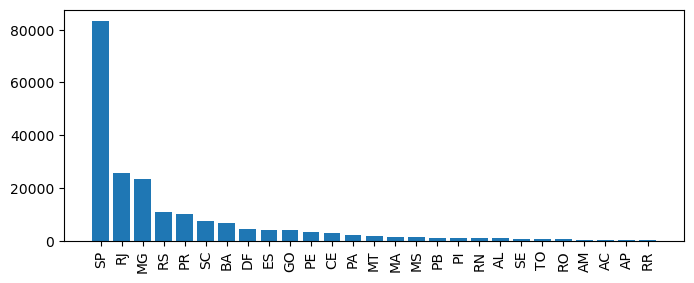

In [10]:
query = """ select customer_state,count(customer_id)
from customers
group by customer_state 
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["state","customers_count" ])
df = df.sort_values(by = "customers_count",ascending= False)

plt.figure(figsize = (8,3))
plt.bar(df["state"], df["customers_count"])
plt.xticks(rotation = 90)
plt.show()

# 6. Calculate the number of orders per month in 2018.


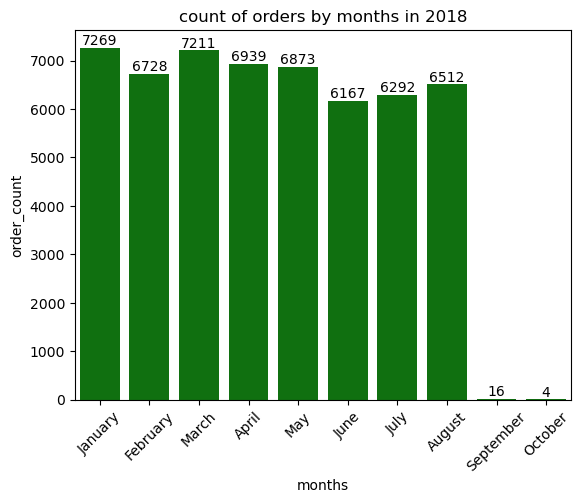

In [9]:
query = """ select monthname(order_purchase_timestamp) months, count(order_id) order_count
from orders where year (order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["months","order_count"])
o = ["January","February","March","April","May","June","July","August","September","October"]

ax = sns.barplot(x=df["months"],y= df["order_count"],data = df, order = o,color = "green")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("count of orders by months in 2018")
plt.show()



# 7. Find the average number of products per order, grouped by customer city.


In [8]:
query = """ with count_per_order as
(SELECT orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id , orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) as average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns=["customer city","average products/order"])
df.head(10)

,customer city,average products/order
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,morro de sao paulo,4.00
6,teixeira soares,4.00
7,cidelandia,4.00
8,curralinho,4.00
9,picarra,4.00


# 8. Calculate the percentage of total revenue contributed by each product category.


In [7]:
query = """ select upper(products.product_category) category,
round(sum(payments.payment_value)/(select sum(payment_value) from payments)* 100,2) sales_percentage
from products join order_items 
on products.product_id = order_items.product_id
join payments
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns=["category","percentage distribution"])
df.head(10)


,category,percentage distribution
0,BED TABLE BATH,21.40
1,HEALTH BEAUTY,20.71
2,COMPUTER ACCESSORIES,19.81
3,FURNITURE DECORATION,17.87
4,WATCHES PRESENT,17.86
5,SPORT LEISURE,17.39
6,HOUSEWARES,13.68
7,AUTOMOTIVE,10.65
8,GARDEN TOOLS,10.47
9,COOL STUFF,9.74


# 9. Identify the correlation between product price and the number of times a product has been purchased.


In [7]:
query = """select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id
group by products.product_category;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns=["category","order_count","price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1,arr2])
print("the correlation between product price and the number of times a product has been purchased are",a[0][-1])

the correlation between product price and the number of times a product has been purchased are -0.10631514167157562


# 10. Calculate the total revenue generated by each seller, and rank them by revenue.


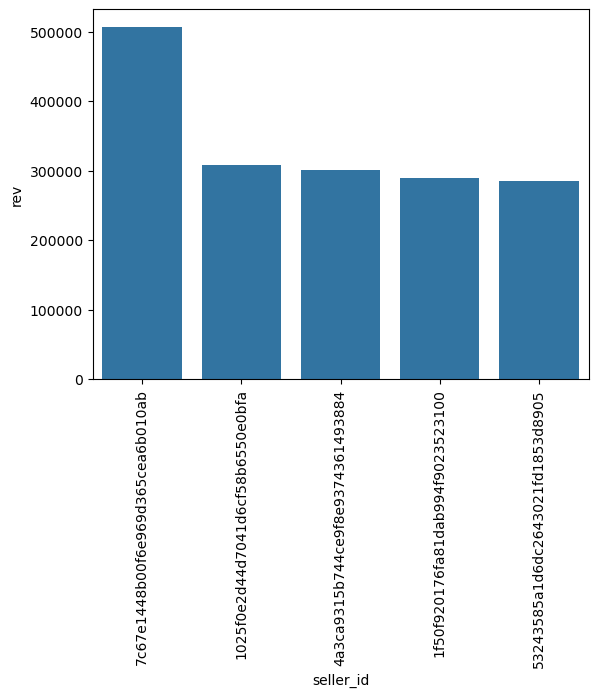

In [18]:
query = """select * ,dense_rank() over (order by rev desc) as rnk from
(select order_items.seller_id,sum(payments.payment_value) as rev
from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id ) as a;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns =["seller_id","rev","rank"])
df_top5 = df.head(5)
sns.barplot(x = "seller_id", y ="rev", data = df_top5)
plt.xticks(rotation=90)
plt.show()





# 11. Calculate the moving average of order values for each customer over their order history.

In [7]:
query = """select customer_id,order_purchase_timestamp,payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp 
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on orders.order_id = payments.order_id) as a;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["customer_id","time","price","mov_avg"])
df


,customer_id,time,price,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,9.49,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# 12. Calculate the cumulative sales per month for each year.


In [8]:
query = """select years,months,payments,sum(payments)
over(order by years,months) as cum_sales from
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payments 
from orders join payments
on orders.order_id = payments.order_id
group by  years, months order by years,months) as a; 
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["year","month","price","cumulative_price"])
df

,year,month,price,cumulative_price
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 13. Calculate the year-over-year growth rate of total sales.


In [15]:
query = """with a as (select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payments 
from orders join payments
on orders.order_id = payments.order_id
group by  years order by years)

select years, ((payments - lag(payments,1) over(order by years)) /
lag(payments,1) over(order by years))*100 from a
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns =["years","yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# 14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.


In [7]:
query ="""with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) as first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count( distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp > 
date_add(first_order, interval 1000 month)
group by a.customer_id)

select 100*(count(distinct a.customer_id)/
 count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id;
"""
cur.execute(query)

data = cur.fetchall()
data

[(None,)]

# 15. Identify the top 3 customers who spent the most money in each year.


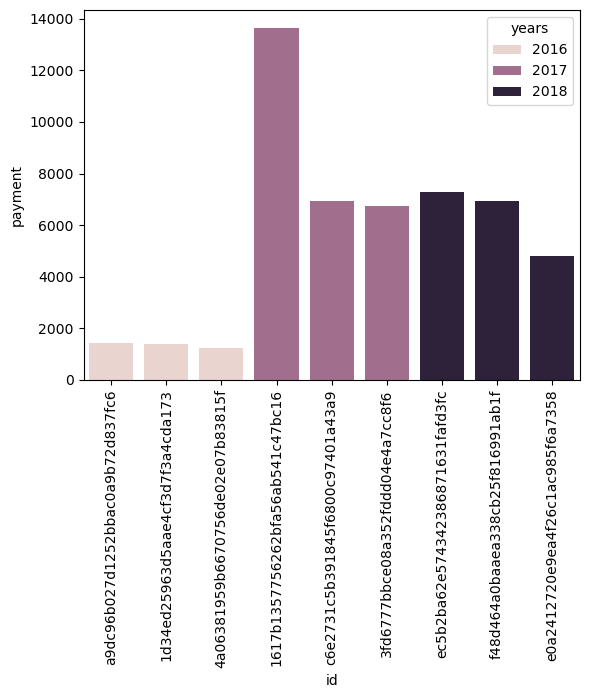

In [6]:
query ="""	select years, customer_id, payment, d_rank
	from 
	(select year(orders.order_purchase_timestamp) years ,
	orders.customer_id,
	sum(payments.payment_value) as payment,
	dense_rank() over(partition by year(orders.order_purchase_timestamp)
	order by sum(payments.payment_value)desc) d_rank
	from orders join payments
	on orders.order_id = payments.order_id
	group by year(orders.order_purchase_timestamp),
	orders.customer_id ) as a
	where d_rank <= 3;
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["years","id","payment","rank"])
sns.barplot (x="id",y = "payment",data = df,hue ="years") 
plt.xticks(rotation = 90)
plt.show()